Представьте, что вы анализируйте данные для международной благотворительной организации, которая оказывает поддержку наиболее нуждающимся странам, на основе этих данных выберите страны, которым помощь нужна в первую очередь.

1. Анализ и предобработка.

    Проанализировать данные (EDA).

    Предобработать данные.

    Скалировать/нормализовать данные.
2. Решите задачу с помощью следующих методов:

    K-means/mini batch k means

    Иерархическая кластеризация

    DBSCAN

3. Для каждого метода определить оптимальное количество кластеров (построить график)

4. Сделайте выводы, определите, каким странам нужно помогать в первую очередь.
  Опишите выделите кластеры. Опишите эталонную страну в каждом кластере.

country - название страны

child_mort - cмертность детей в возрасте до 5 лет на 1000 живорождений

exports - экспорт товаров и услуг на душу населения. Приведено в % от ВВП на душу населения

health - общие расходы на здравоохранение на душу населения. Указаны как % от ВВП на душу населения

Imports - импорт товаров и услуг на душу населения. Указано в % от ВВП на душу населения.

Income - чистый доход на человека

Inflation - измерение годового темпа роста общего ВВП

life_expec - ожидаемая продолжительность жизни

total_fer - ожидаемая рождаемость

gdpp - ВВП на душу населения

## Анализ и предобработка

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/Lab4.csv')
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


Нет пропусков. Жизнь хороша.

In [ ]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [ ]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Построим гистограммы распределения для признаков

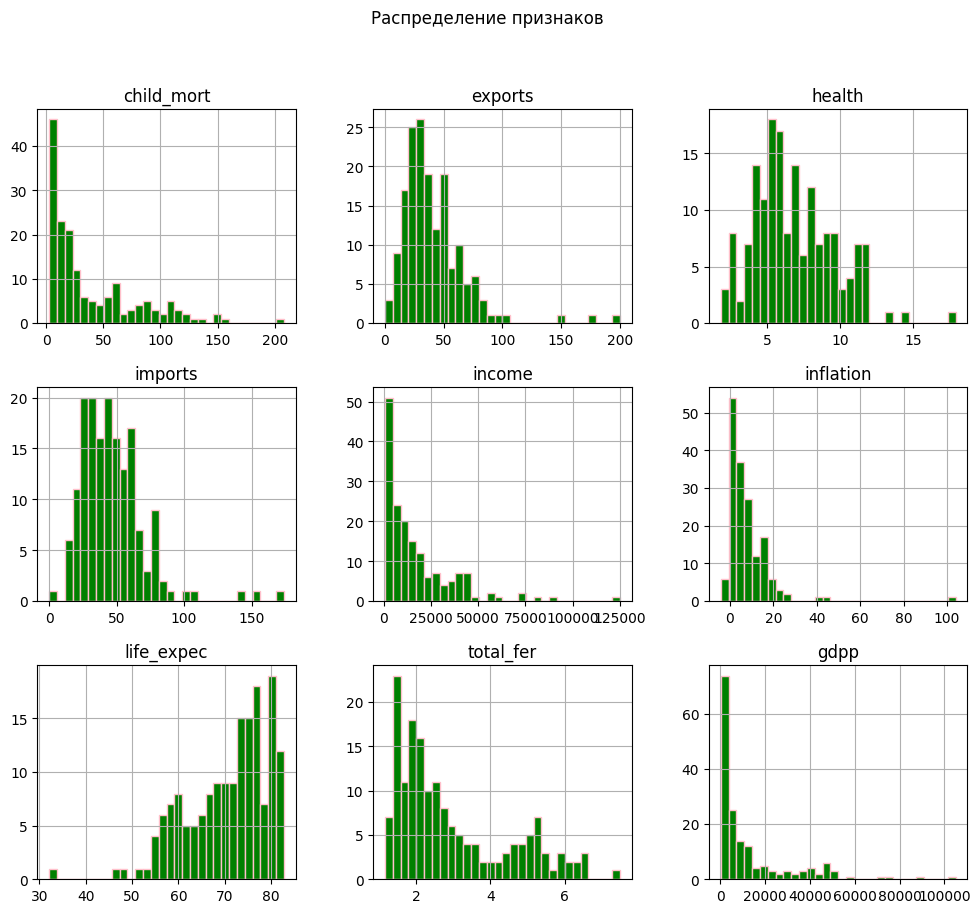

In [ ]:
df.hist(figsize=(12, 10), bins=30, color='green', edgecolor='pink')
plt.suptitle('Распределение признаков')
plt.show()

Рассмотри некоторые признаки, которые могут иметь выбросы

In [ ]:
possible_outliners = ['child_mort', 'income', 'inflation', 'gdpp']
for p in possible_outliners:
  print(f'Признак: {p} || {df[p].min()} || {df[p].max()} ||')

Признак: child_mort || 2.6 || 208.0 ||
Признак: income || 609 || 125000 ||
Признак: inflation || -4.21 || 104.0 ||
Признак: gdpp || 231 || 105000 ||


Видим большие разбросы, но скорее всего это какая-то нестабильность в странах(?)

Построим матрицу корреляций

In [ ]:
df_numeric=df.drop(columns=['country'])

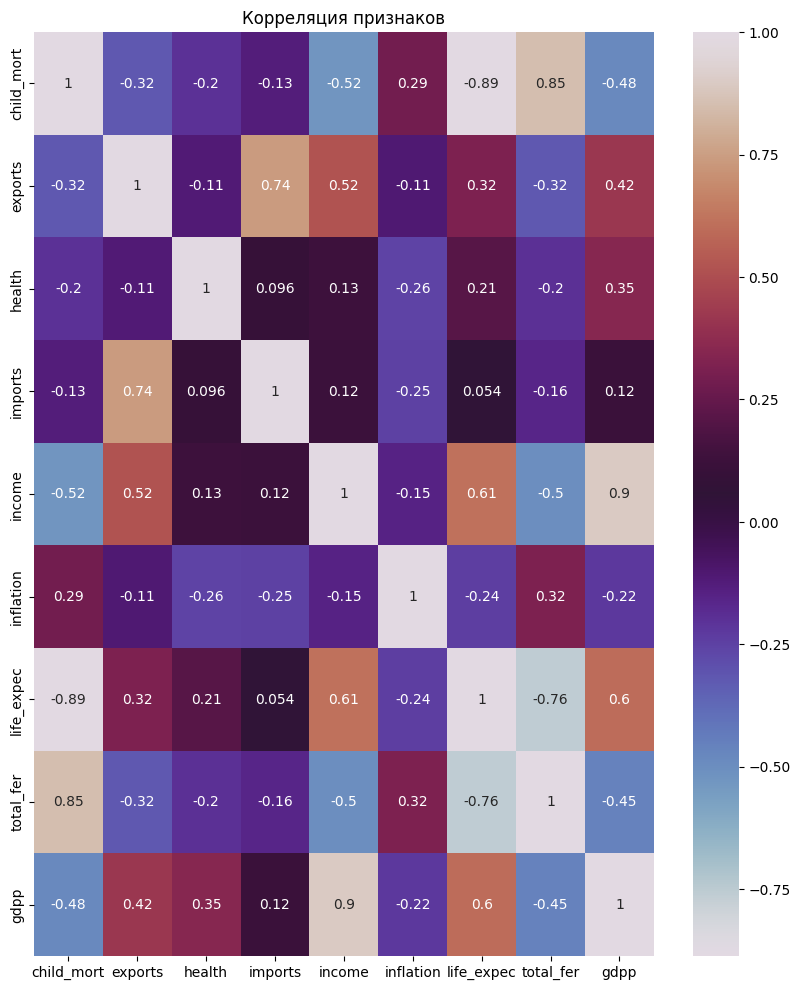

In [ ]:
plt.figure(figsize=(10, 12))
sns.heatmap(df_numeric.corr(), cmap='twilight', annot=True)
plt.title('Корреляция признаков')
plt.show()

Видим, что у child_mort отрицательно коррелируется с life_expec. Низкая смертность зависит от продолжительности жизни, логично

gdpp и income имеют сильную положительную корреляцию (0.9).

Попробуем построить боксплот, чтобы оценить разброс

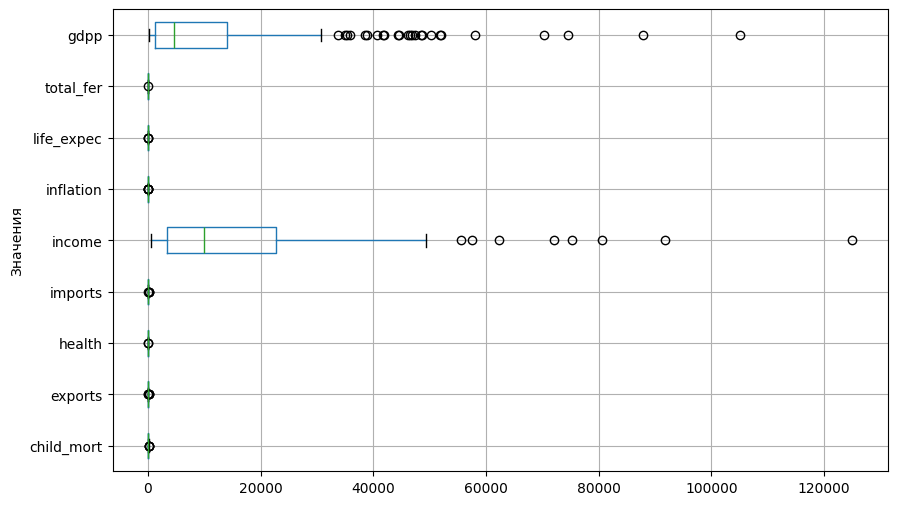

In [ ]:
df.boxplot(figsize=(10, 6), vert=False, grid=True)
plt.ylabel('Значения')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

df_sc = pd.DataFrame(scaler.fit_transform(df_numeric), columns=df_numeric.columns)

df_sc.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02
mean,-3.722904e-17,2.127373e-16,5.504579e-16,2.765585e-16,-7.977650e-17,-1.063687e-17,3.696311e-16,3.044803e-16,5.850277e-17
std,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00
min,-8.871383e-01,-1.500192e+00,-1.827827e+00,-1.939940e+00,-8.603259e-01,-1.137852e+00,-4.337186e+00,-1.191250e+00,-6.968005e-01
25%,-7.466190e-01,-6.333367e-01,-6.922106e-01,-6.914785e-01,-7.174558e-01,-5.666409e-01,-5.927576e-01,-7.639023e-01,-6.366596e-01
50%,-4.717981e-01,-2.235279e-01,-1.810007e-01,-1.487432e-01,-3.738080e-01,-2.269504e-01,2.869576e-01,-3.564309e-01,-4.544309e-01
75%,5.926666e-01,3.747198e-01,6.515412e-01,4.913530e-01,2.942370e-01,2.816364e-01,7.042584e-01,6.175252e-01,5.942100e-02
max,4.221297e+00,5.813835e+00,4.047436e+00,5.266181e+00,5.611542e+00,9.129718e+00,1.380962e+00,3.009349e+00,5.036507e+00


In [ ]:
df_sc.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


## Решим задачу с помощью запрашиваемых методов

K-means/mini batch k means

Попробуем определить оптимальное количество кластеров. Воспользуемся методом [локтя](https://habr.com/ru/companies/skillfactory/articles/877684/). Мы будем строить график зависимости суммы внутрикластерных расстояний от числа кластеров и искать точку, где этот график начинает «выпрямляться».

Я так понимаю, что нам нужно выбрать наиболее релевантные признаки к нашей проблеме. Мне кажется, что к нуждающимся странам можно отнести страны, у оторых высокая смнртность, низкая ожидаемая продолжительность жизни, низкий доход на человека, низкий ВВП на душу населения, рождаемость и низкие расходы на здравоохранение. То есть берем только child_mort, life_expec, Income, gdpp, health, total_fer.

In [ ]:
print(df_sc.columns)

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp'],
      dtype='object')


In [ ]:
features = ['child_mort', 'life_expec', 'income', 'gdpp', 'health', 'total_fer']

df_sc_selected = df_sc[features]

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df_sc_selected)
    inertia.append(kmeans.inertia_)


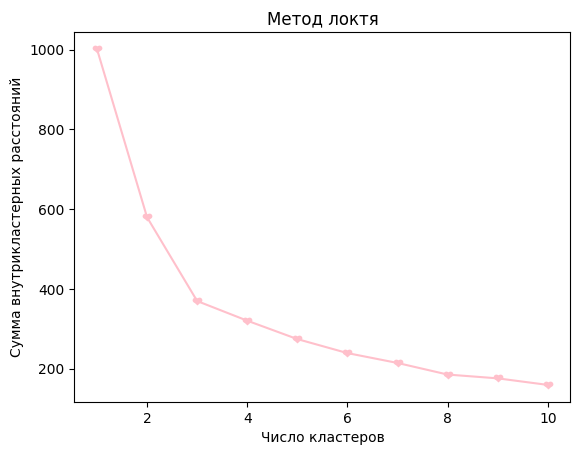

In [ ]:
plt.plot(range(1, 11), inertia, marker='$❤$', color='pink')
plt.title('Метод локтя')
plt.xlabel('Число кластеров')
plt.ylabel('Сумма внутрикластерных расстояний')
plt.show()

Как будто по картинке можем предположить, что локоть начинается на 4 числе(?). Получается 4, это наилучшее количсетво кластеров.

In [ ]:
kmeans = KMeans(n_clusters=4)
df['cluster_kmeans'] = kmeans.fit_predict(df_sc_selected)

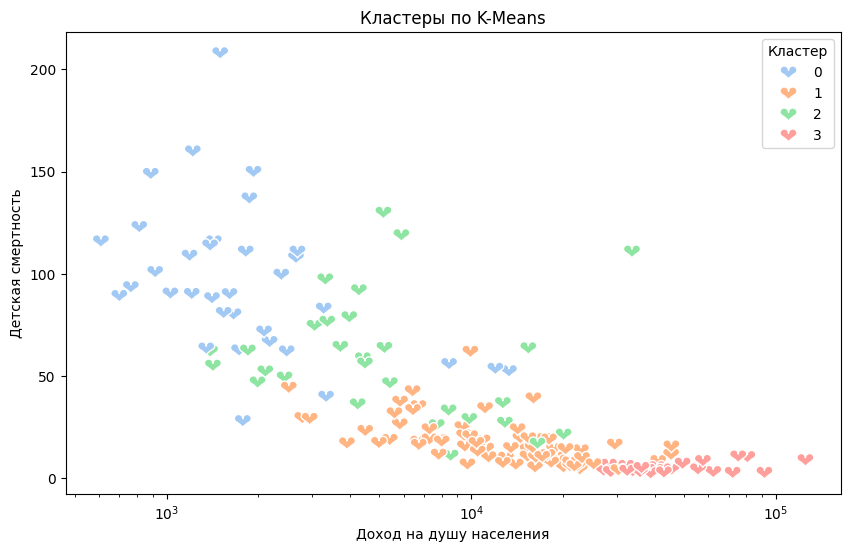

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['income'], y=df['child_mort'], hue=df['cluster_kmeans'], palette='pastel', s=150, marker='$❤$')
plt.xscale('log')
plt.xlabel('Доход на душу населения')
plt.ylabel('Детская смертность')
plt.title('Кластеры по K-Means')
plt.legend(title='Кластер')
plt.show()

Теперь проведем иерархическую кластеризацию и посмотрим на дендрограмму

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

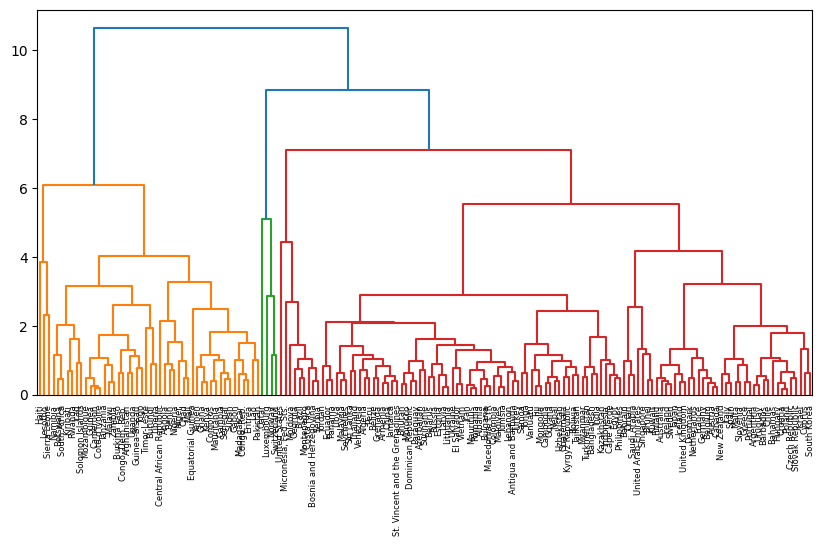

In [ ]:
linkage_matrix = linkage(df_sc_selected, method='complete')
plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix, labels=df['country'].values, leaf_rotation=90, leaf_font_size=6)

plt.show()

Выбираем количество кластеров - 4

In [ ]:
df['cluster_hierarchical'] = fcluster(linkage_matrix, t=4, criterion='maxclust')

DBSCAN



In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
from sklearn.neighbors import NearestNeighbors

In [ ]:
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(df_sc_selected)
distances, indices = neighbors_fit.kneighbors(df_sc_selected)
distances = np.sort(distances, axis=0)
distances = distances[:, 3]

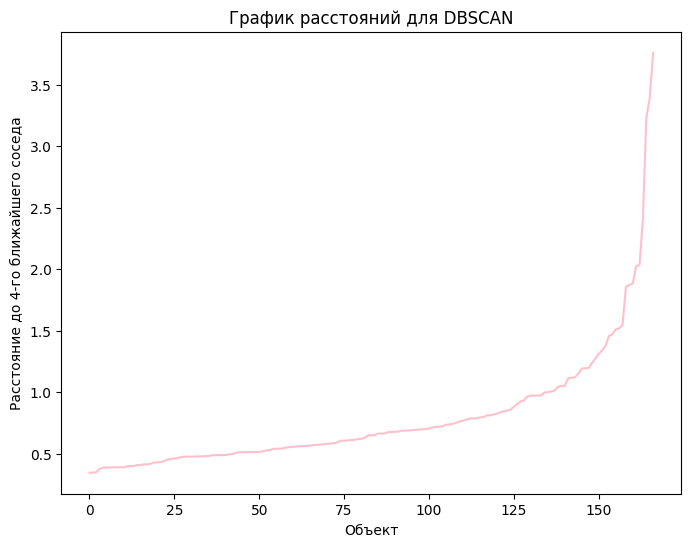

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(distances, color='pink')
plt.title('График расстояний для DBSCAN')
plt.xlabel('Объект')
plt.ylabel('Расстояние до 4-го ближайшего соседа')
plt.show()

Видим излом, как будто в 1.5

In [ ]:
dbscan = DBSCAN(eps=1.5, min_samples=4)
df['cluster_dbscan'] = dbscan.fit_predict(df_sc_selected)

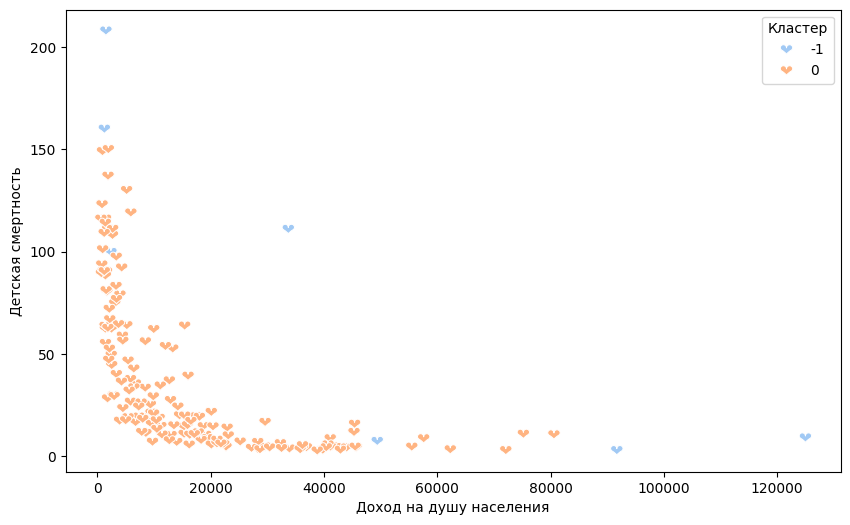

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['income'], y=df['child_mort'], hue=df['cluster_dbscan'], palette='pastel', s=80, marker='$❤$')
plt.xlabel('Доход на душу населения')
plt.ylabel('Детская смертность')
plt.legend(title='Кластер')
plt.show()

Проанализируем результаты кластеризации, чтобы понять какой стране нужно помогать в первую очередь

In [ ]:
df.groupby('cluster_kmeans')[features].mean()

,child_mort,life_expec,income,gdpp,health,total_fer
cluster_kmeans,,,,,,
0,4.660714,80.378571,37010.714286,39357.142857,9.966429,1.737500
1,91.610417,59.239583,3897.354167,1909.208333,6.433542,4.992083
2,21.614286,73.004762,12801.071429,6581.809524,6.169048,2.277619
3,6.814286,79.471429,80642.857143,59785.714286,4.592857,1.817143


Страны из кластера 0 с низкой детской смертностью и высоким доходом.

Страны из кластера 1 с высокой детской смертностью и низким доходом.

Страны из кластера 2 с нормальной детской смертностью и доходом.

Страны из кластера 3  высокими доходами и низкой детской смертностью.

Можно сделать вывод, что странам из кластера 1 нужно помогать в первую очередь.

In [ ]:
df.groupby('cluster_dbscan')[features].mean()

,child_mort,life_expec,income,gdpp,health,total_fer
cluster_dbscan,,,,,,
-1,85.400000,62.00,43557.142857,34718.714286,9.010000,3.238571
0,36.208125,70.93,15989.143750,12012.393750,6.719688,2.935250


Кластер -1 имеет:

Высокие доходы и ВВП на душу населения, высокую детскую смертность и низкую продолжительность жизни

Кластер 0:

 Страны с умеренным уровнем дохода, высокой детской смертностью и умеренной продолжительностью жизни

In [ ]:
df.groupby('cluster_hierarchical')[features].mean()

,child_mort,life_expec,income,gdpp,health,total_fer
cluster_hierarchical,,,,,,
1,91.610417,59.239583,3897.354167,1909.208333,6.433542,4.992083
2,4.875000,81.000000,83625.000000,84425.000000,7.640000,1.792500
3,14.700000,74.344444,14144.444444,10216.666667,11.602222,1.864444
4,17.377358,74.964151,20889.528302,15506.811321,6.551226,2.157925


Кластер 1 включает страны с очень высокой детской смертностью и низким уровнем дохода.

Кластер 2 содержит страны с низкой детской смертностью, высокой продолжительностью жизни, высокий доход,высокий ВВП на душу населения, низкую рождаемость

Кластер 3 содержит какие-то средние значения по всем показателям

Кластер 4 тоже содержит умеренные значения.

Вывод: помогать надо странам из кластера 1

In [ ]:
df_kmeans = df[['country', 'cluster_kmeans']].groupby('cluster_kmeans')['country'].apply(list)
df_hierarchical = df[['country', 'cluster_hierarchical']].groupby('cluster_hierarchical')['country'].apply(list)
df_dbscan = df[['country', 'cluster_dbscan']].groupby('cluster_dbscan')['country'].apply(list)
print(df_kmeans)
print(df_hierarchical)
print(df_dbscan)


cluster_kmeans
0    [Australia, Austria, Bahamas, Belgium, Canada,...
1    [Afghanistan, Angola, Benin, Botswana, Burkina...
2    [Albania, Algeria, Antigua and Barbuda, Argent...
3    [Brunei, Kuwait, Luxembourg, Norway, Qatar, Si...
Name: country, dtype: object
cluster_hierarchical
1    [Afghanistan, Angola, Benin, Botswana, Burkina...
2             [Luxembourg, Norway, Qatar, Switzerland]
3    [Bosnia and Herzegovina, Brazil, Costa Rica, G...
4    [Albania, Algeria, Antigua and Barbuda, Argent...
Name: country, dtype: object
cluster_dbscan
-1    [Equatorial Guinea, Haiti, Lesotho, Luxembourg...
 0    [Afghanistan, Albania, Algeria, Angola, Antigu...
Name: country, dtype: object


Попробуем найти эталонную страну в каждом кластере

Для kmeans

In [ ]:
from scipy.spatial.distance import euclidean

In [ ]:
centroids = df.groupby('cluster_kmeans')[features].mean()

In [ ]:
def find_representative(cluster_label):
    cluster_data = df[df['cluster_kmeans'] == cluster_label]
    centroid = centroids.loc[cluster_label]
    distances = cluster_data[features].apply(lambda x: euclidean(x, centroid), axis=1)
    return cluster_data.loc[distances.idxmin(), 'country']
etalon_countries = {cluster: find_representative(cluster) for cluster in centroids.index}
print(etalon_countries)

{0: 'United Kingdom', 1: 'Sudan', 2: 'Serbia', 3: 'Singapore'}


Для иерархической

In [ ]:
centroids_hierarchical = df.groupby('cluster_hierarchical')[features].mean()

In [ ]:
def find_representative(cluster_label, cluster_column):
    cluster_data = df[df[cluster_column] == cluster_label]
    centroid = centroids_hierarchical.loc[cluster_label]
    distances = cluster_data[features].apply(lambda x: euclidean(x, centroid), axis=1)
    return cluster_data.loc[distances.idxmin(), 'country']
etalon_countries_hierarchical = {cluster: find_representative(cluster, 'cluster_hierarchical')
                                 for cluster in centroids_hierarchical.index}
print(etalon_countries_hierarchical)

{1: 'Sudan', 2: 'Norway', 3: 'Brazil', 4: 'Estonia'}


Для DBSCAN

(кажется, у меня здесь не очень получилось. DBSCAN создал только один кластер 0, а все остальные точки он пометил как выбросы (кластер -1))

Найдем эталонную страну для одного кластера

In [ ]:
centroid_dbscan_0 = df[df['cluster_dbscan'] == 0][features].mean()

In [ ]:
df['cluster_dbscan'].value_counts()

,count
cluster_dbscan,
0,160
-1,7


In [ ]:
cluster_0_data = df[df['cluster_dbscan'] == 0]
distances = cluster_0_data[features].apply(lambda x: euclidean(x, centroid_dbscan_0), axis=1)

representative_country = cluster_0_data.loc[distances.idxmin(), 'country']
print(representative_country)

Uruguay
